# Reservoir_Learning.ipynb — Master Comparison Notebook

**Paper:** *Quantum Reservoir Computing for Realized Volatility Forecasting* (arXiv:2505.13933)

## Purpose

This is the **main analysis notebook** that:
1. Implements the linear baseline models (HAR, HARX, AR(1), AR(3), ARMAX) via rolling-window estimation
2. Loads pre-computed predictions from the other notebooks (LSTM, classical reservoir) and the Julia quantum pipeline (QR1, QR2)
3. Runs the **Model Confidence Set (MCS)** test — the paper's primary evaluation method — using both MSE and QLIKE loss functions
4. Runs pairwise **Diebold-Mariano (DM)** significance tests between all 11 models

## All 11 Models Compared

| Model | Type | Source | Features |
|-------|------|--------|----------|
| HAR | Linear | This notebook | RV (daily, weekly, monthly lags) |
| HARX | Linear | This notebook | HAR + all exogenous macro vars |
| AR(1) | Linear | This notebook | RV with 1 lag |
| AR(3) | Linear | This notebook | RV with 3 lags |
| ARMAX | Linear | This notebook | AR(3) + all exogenous macro vars |
| LSTM | Neural net | LSTM.ipynb | RV only, hidden=60 |
| LSTMX | Neural net | LSTM.ipynb | 11 features, hidden=50 |
| CRL (RC) | Reservoir | classical_reservoir.ipynb | RV only, N=50 neurons |
| CRLX (RCX) | Reservoir | classical_reservoir.ipynb | 11 features, N=20 neurons |
| QR1 | Quantum reservoir | Julia pipeline (pre-computed) | 7 features selected |
| QR2 | Quantum ensemble | Julia pipeline (pre-computed) | 7 features, 2 reservoirs |

## Prerequisites

Run these **in order** before this notebook:
1. `python preprocess.py` (generates dff.csv and Data_raw.csv)
2. `LSTM.ipynb` (generates LSTM/lstm60_predictions.csv and LSTM/lstmx50_predictions.csv)
3. `classical_reservoir.ipynb` (generates Classical_Reservoir_learning/*.csv)
4. `predict_result.csv` must be present (shipped with repo — quantum predictions)


## Statistical Testing Methods

**Model Confidence Set (MCS)** — Hansen, Lunde & Nason (2011):
- Identifies the set of models that produce statistically indistinguishable loss
- Iteratively eliminates the worst-performing model until the null hypothesis ("all remaining models are equally good") cannot be rejected
- Models with p-value > 0.05 are "included" in the best model set
- The model with p-value = 1.0 is the last survivor (best model)
- Uses Range-type test statistic T_{R,M} and stationary bootstrap

**QLIKE (Quasi-Likelihood) Loss** — Patton (2011):
- Asymmetric loss function: penalizes underestimation of volatility more heavily
- Formula: QLIKE = sum( sigma^2/h^2 - log(sigma^2/h^2) - 1 )
- Robust to noise in volatility proxy
- Used alongside MSE to evaluate models from two different perspectives


## Data Load

In [46]:
# =============================================================================
# Imports
# =============================================================================
# Core libraries for data manipulation, statistics, and plotting.
# statsmodels provides OLS, AutoReg, and ARIMA for the linear models.
# The optional imports (yfinance, pandas_datareader, nolitsa) are from the
# original notebook but are NOT used in the core forecasting pipeline.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import glob as globmod  # For finding CRL prediction files by pattern

# Optional imports (not used in forecasting — only for exploratory analysis)
try:
    import yfinance as yf
except ImportError:
    pass
try:
    import pandas_datareader.data as web
    import pandas_datareader as pdr
except (ImportError, TypeError):
    pass
try:
    from nolitsa import lyapunov, data
except ImportError:
    pass


In [47]:
# =============================================================================
# Load the raw dataset (Data_raw.csv)
# =============================================================================
# 816 rows (monthly, Jan 1950 - Dec 2017), 16 columns.
# This is the un-differenced version. The ADF stationarity test and
# differencing happen in cell 12 below (same as preprocess.py).
df = pd.read_csv("Data_raw.csv", header=0, index_col=0)


<Axes: xlabel='Date'>

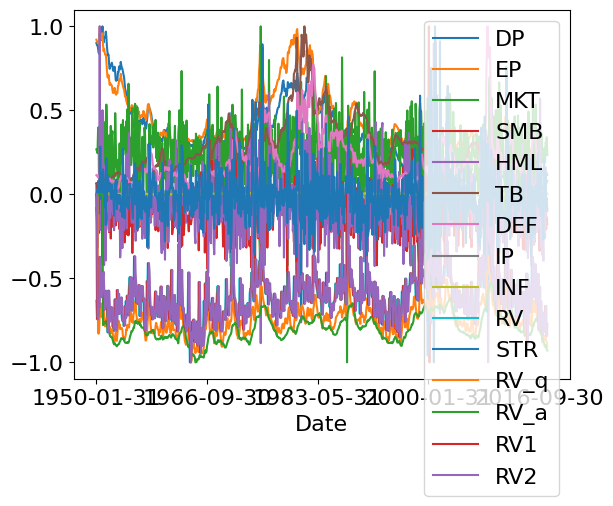

In [48]:
df.plot()

## Chaotic Test on RV

A positive Lyapunov exponent is typically indicative of chaos, signifying sensitive dependence on initial conditions. In contrast, a negative exponent suggests that nearby trajectories in the phase space converge over time, leading to predictable behavior.

In [49]:
def phase_space_reconstruct(series, emb_dim, tau):
    n = len(series)
    if n < (emb_dim - 1) * tau + 1:
        raise ValueError("Time series is too short for the chosen embedding dimension and time delay.")

    reconstructed = np.empty((n - (emb_dim - 1) * tau, emb_dim))
    for i in range(emb_dim):
        reconstructed[:, i] = series[i * tau:n - (emb_dim - 1) * tau + i * tau]

    return reconstructed

# Function to calculate the largest Lyapunov exponent using nolitsa
def calculate_lyapunov_exponent_nolitsa(series, emb_dim=3, tau=2):
    # Reconstruct the phase space
    embedded = phase_space_reconstruct(series, emb_dim, tau)

    # Calculate the Lyapunov exponent
    # The maxt and window parameters may need adjustment depending on your data
    l = lyapunov.mle(embedded, maxt=100, window=10)[0]
    return l

time_series = df['RV'].values

# Calculate the Lyapunov exponent for 'RV'
le_rv = calculate_lyapunov_exponent_nolitsa(time_series)
print("Largest Lyapunov Exponent for 'RV':", le_rv)

Largest Lyapunov Exponent for 'RV': -3.69673749694055


In [50]:
import numpy as np

def time_delay_embedding(series, embed_dim, tau):
    n_points = len(series) - (embed_dim - 1) * tau
    if n_points <= 0:
        raise ValueError("Time series is too short for the chosen embedding dimension and time delay.")

    reconstructed = np.empty((n_points, embed_dim))
    for i in range(embed_dim):
        reconstructed[:, i] = series[i * tau : i * tau + n_points]

    return reconstructed

# Example usage
time_series = df['RV'].dropna().values  # Replace 'INF' with your time series column

# Set the embedding dimension and time delay
embed_dim = 3
tau = 1

# Perform time delay embedding
embedded_data = time_delay_embedding(time_series, embed_dim, tau)

# Check the shape of the embedded data
print("Shape of embedded_data after embedding:", embedded_data.shape)

# Proceed with the rest of your analysis or plotting


Shape of embedded_data after embedding: (814, 3)


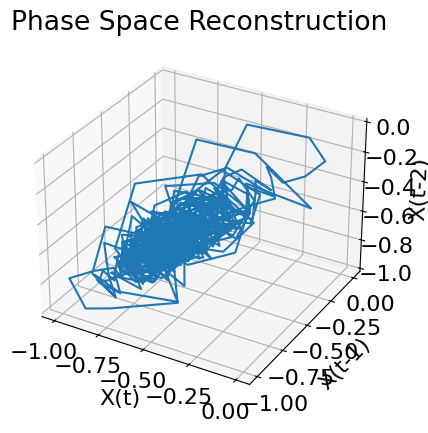

In [51]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plotting the trajectory in the phase space
ax.plot(embedded_data[:, 0], embedded_data[:, 1], embedded_data[:, 2])

ax.set_xlabel('X(t)')
ax.set_ylabel('X(t-1)')
ax.set_zlabel('X(t-2)')

plt.title('Phase Space Reconstruction')
plt.show()


In [52]:
import numpy as np

def zero_one_test(time_series, c=0.9, n=10):
    """
    0-1 Test for chaos in a time series.

    :param time_series: Time series data as a numpy array.
    :param c: A constant typically set between 0 and 2*pi.
    :param n: The number of iterations to average over, more gives better approximations.
    :return: A value close to 0 indicates regular dynamics, close to 1 indicates chaos.
    """
    N = len(time_series)
    p = np.arange(1, N+1)
    theta = p * c

    # Compute K
    K = np.empty(n)
    for j in range(1, n+1):
        # Random phase
        phi = 2 * np.pi * np.random.rand()

        # Translation variables
        x = np.cumsum(time_series * np.cos(theta + phi))
        y = np.cumsum(time_series * np.sin(theta + phi))

        # Mean square displacement
        m = np.mean(x**2 + y**2)

        # Diffusion coefficient
        K[j-1] = m / (N**2)

    # Median of diffusion coefficients
    K_med = np.median(K)

    # 0-1 test statistic
    if K_med > 0.05:
        return 1  # Chaotic
    else:
        return 0  # Regular

# Example usage
# Assuming df is your DataFrame and 'INF' is the column you're analyzing
time_series = df['RV'].dropna().values
test_result = zero_one_test(time_series)
print("0-1 Test result:", test_result)


0-1 Test result: 0


## Unit Root Test for Stationarity

In [53]:
# =============================================================================
# Augmented Dickey-Fuller Stationarity Test & Differencing
# =============================================================================
# This cell performs the same ADF test as preprocess.py, but inline.
# For each column in the raw dataset:
#   - If p-value > 0.05 (non-stationary): difference it and prefix with 'diff_'
#   - If p-value <= 0.05 (stationary): keep as-is
#
# Typically, DP and TB are differenced; all others are stationary.
# This creates the 'dff' DataFrame used by all downstream models.
# =============================================================================
def check_stationarity(data, column):
    """
    Run ADF test on a time series.
    Returns (p_value, test_statistic, critical_values).
    Low p-value (<0.05) means the series IS stationary.
    """
    result = sm.tsa.adfuller(data.dropna())
    test_statistic = result[0]
    p_value = result[1]
    critical_values = result[4]
    return p_value, test_statistic, critical_values

# Test each column and build the differenced DataFrame
stationarity_results = {}
for col in df.columns:
    p_value, test_statistic, critical_values = check_stationarity(df[col], col)
    stationarity_results[col] = {'p_value': p_value, 'test_statistic': test_statistic, 'critical_values': critical_values}

dff = pd.DataFrame(index=df.index)

# Difference non-stationary columns, keep stationary ones
for col, results in stationarity_results.items():
    if results['p_value'] > 0.05:
        dff[f'diff_{col}'] = df[col].diff()  # First difference for stationarity
    else:
        dff[col] = df[col]  # Already stationary

# Print ADF test results for reference
for col, results in stationarity_results.items():
    print(f"Column: {col}")
    print(f"ADF Statistic: {results['test_statistic']}")
    print(f"p-value: {results['p_value']}")
    for key, value in results['critical_values'].items():
        print(f'Critical Value {key}: {value}')
    print("\n")

print(dff.head())


Column: DP
ADF Statistic: -2.7527226229890025
p-value: 0.06535077209158752
Critical Value 1%: -3.4385197724757233
Critical Value 5%: -2.8651460209504114
Critical Value 10%: -2.5686901720199313


Column: EP
ADF Statistic: -3.6943955100307906
p-value: 0.004192680498176978
Critical Value 1%: -3.4384589869479023
Critical Value 5%: -2.8651192271940693
Critical Value 10%: -2.5686758988725416


Column: MKT
ADF Statistic: -26.390293249392222
p-value: 0.0
Critical Value 1%: -3.438399099271788
Critical Value 5%: -2.8650928286782857
Critical Value 10%: -2.568661836350634


Column: SMB
ADF Statistic: -16.940495754935345
p-value: 9.62562251646106e-30
Critical Value 1%: -3.4384189633001956
Critical Value 5%: -2.86510158480911
Critical Value 10%: -2.568666500743605


Column: HML
ADF Statistic: -24.20913407078814
p-value: 0.0
Critical Value 1%: -3.438399099271788
Critical Value 5%: -2.8650928286782857
Critical Value 10%: -2.568661836350634


Column: TB
ADF Statistic: -2.0172723697575683
p-value: 0.279

In [54]:
# =============================================================================
# QLIKE Loss Function
# =============================================================================
# Quasi-Likelihood loss from Patton (2011). Used for volatility forecast
# evaluation. See LSTM.ipynb cell 14 for full documentation.
#
# Formula: QLIKE = sum( |actual|/|forecast| - log(|actual|/|forecast|) - 1 )
# Perfect forecast (actual=forecast) gives QLIKE=0.
# =============================================================================
def compute_qlike(forecasts, actuals):
    """
    Compute sum-based QLIKE loss.
    Uses absolute values because RV is in log-space (negative values).
    """
    forecasts = np.abs(forecasts)
    actuals = np.abs(actuals)
    ratio = actuals / forecasts
    qlike = np.sum(ratio - np.log(ratio) - 1)
    return qlike


In [55]:
#dff=pd.read_csv("dff.csv",header=0,index_col=0)

# Forecast Models

## HAR (Heterogeneous Autoregressive)

 -  HAR model, the model includes the first lag of the variable along with other lagged terms such as weekly and monthly lags (in the context of daily data). For our monthly data, these lagged terms would be the first lag (1-month lag), a quarterly lag (3-month lag), and an annual lag (12-month lag).

 - Estimate the HAR model using a rolling window, keeping the last 245 observations for the testing set.

 - Rolling Window Estimation: For each step in the test set, retrain the model using the most recent data up to that point.

$RV_t = \beta_0 + \beta_1 \times RV_{t-1} + \beta_2 \times RV_{\text{quarterly}, t-1} + \beta_3 \times RV_{\text{annual}, t-1} + \varepsilon_t
$

In [56]:
# =============================================================================
# HAR Model — Heterogeneous Autoregressive (Corsi, 2009)
# =============================================================================
# The HAR model captures multi-horizon volatility persistence using three
# lag components that represent different trader horizons:
#
# Formula (paper Section III.B):
#   RV_t = beta_0 + beta_1 * RV_{t-1}        (daily/short-term)
#                  + beta_2 * RV_q_{t-1}      (quarterly/medium-term)
#                  + beta_3 * RV_a_{t-1}      (annual/long-term)
#                  + epsilon_t
#
# Where:
#   RV_{t-1}   = previous month's realized volatility
#   RV_q_{t-1} = average of past 3 months' RV (quarterly component)
#   RV_a_{t-1} = average of past 12 months' RV (annual component)
#
# Estimated via OLS with a constant term.
# =============================================================================

# Create the three HAR lag features
dff['RV_lag1'] = dff['RV'].shift(1)  # 1-month lag
dff['RV_quarterly_lag'] = dff['RV'].rolling(window=3).mean().shift(1)   # 3-month avg, lagged
dff['RV_annual_lag'] = dff['RV'].rolling(window=12).mean().shift(1)     # 12-month avg, lagged

# Fill NaN from rolling/shift operations
dff = dff.fillna(0)

# Split data: first 571 months for training, last 245 for testing
train = dff.iloc[:-245]
test = dff.iloc[-245:]

def estimate_har_model(data):
    """
    Fit HAR model via OLS on the given training data.
    Returns the fitted statsmodels OLS results object.
    """
    X = data[['RV_lag1', 'RV_quarterly_lag', 'RV_annual_lag']]
    y = data['RV']
    model = sm.OLS(y, sm.add_constant(X)).fit()
    return model


In [57]:
# =============================================================================
# HAR: Rolling-Window Out-of-Sample Forecasting
# =============================================================================
# For each of the 245 test months:
#   1. Train HAR on the preceding 571-month window
#   2. Predict the next month's RV using the 3 HAR lag features
#   3. Slide the window forward by 1 month
#
# Window indexing:
#   rolling_window_start: first row of training data (slides forward)
#   rolling_window_end:   first row of test data (= last train row + 1)
#   train_data: rows [start : end) — 571 rows, fixed size
#   X_test: row [end] — the single test observation
# =============================================================================

# Start with full 571-month training window
rolling_window_start = 0
rolling_window_end = len(train)  # = 571: rows 0-570 for training, row 571 = first test

predictions_har = []

for t in range(len(test)):
    # Fit HAR model on current training window
    train_data = dff.iloc[rolling_window_start:rolling_window_end]
    model = estimate_har_model(train_data)

    # Extract test features and add constant for prediction
    X_test = dff[['RV_lag1', 'RV_quarterly_lag', 'RV_annual_lag']].iloc[rolling_window_end:rolling_window_end+1]
    X_test = sm.add_constant(X_test, has_constant='add')

    # Make 1-step-ahead prediction
    pred = model.predict(X_test)
    predictions_har.append(pred.values[0])

    # Slide window forward by 1 month (fixed-size rolling window)
    rolling_window_start += 1
    rolling_window_end += 1


In [58]:
# =============================================================================
# HAR: Compute and Display Forecast Metrics
# =============================================================================
actual = test['RV'].values  # True RV for 245 test months
predictions_har = predictions_har[-len(actual):]  # Ensure alignment

mse = mean_squared_error(actual, predictions_har)
rmse = np.sqrt(mean_squared_error(actual, predictions_har))
mae = mean_absolute_error(actual, predictions_har)
mape = np.mean(np.abs((actual - predictions_har) / actual)) * 100

def compute_hit_rate(predictions, actual):
    """
    Compute directional accuracy (hit rate): what fraction of the time
    does the model correctly predict whether RV will go up or down?
    
    Parameters
    ----------
    predictions, actual : array-like
        Predicted and actual RV values (245 elements each).
    
    Returns
    -------
    float
        Hit rate between 0 and 1 (higher is better; 0.5 = random).
    """
    predictions = np.array(predictions)
    actual = np.array(actual)
    # Compare direction of consecutive changes
    pred_direction = (np.diff(predictions) > 0).astype(int)
    actual_direction = (np.diff(actual) > 0).astype(int)
    hits = np.sum(pred_direction == actual_direction)
    hit_rate = hits / len(pred_direction)
    return hit_rate

hit_rate = compute_hit_rate(predictions_har, actual)

print(f"Hit Rate: {hit_rate}")
print(f"Mean Square Error (MSE): {mse}")
print(f"Root Mean Square Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")


Hit Rate: 0.4426229508196721
Mean Square Error (MSE): 0.011922732085577712
Root Mean Square Error (RMSE): 0.10919126377864537
Mean Absolute Error (MAE): 0.08466094358604147
Mean Absolute Percentage Error (MAPE): 21.68358601213334%


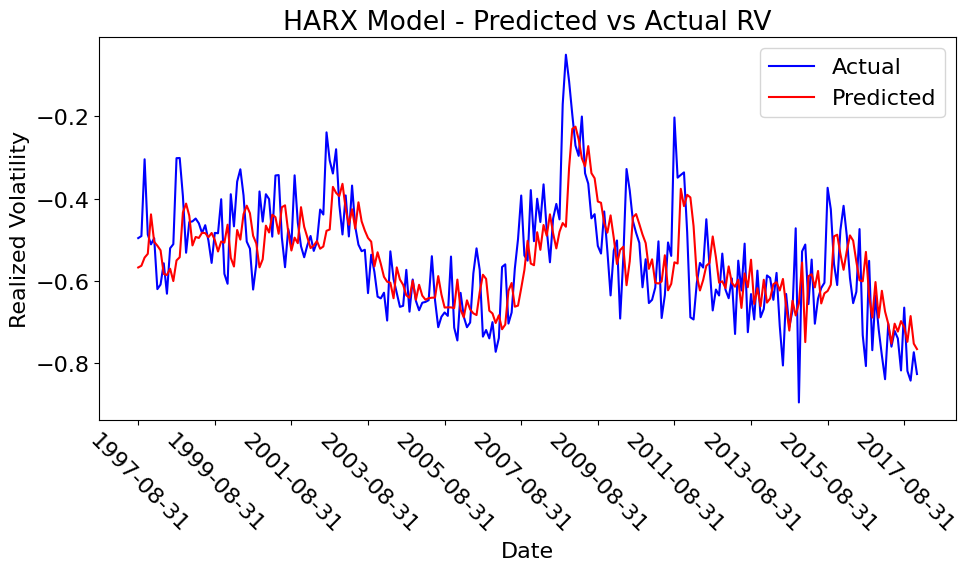

In [59]:
# Plotting the actual vs predicted values
plt.figure(figsize=(10, 6))
plt.rcParams['font.size'] = 16
plt.plot(test.index, actual, label='Actual', color='blue')
plt.plot(test.index, predictions_har, label='Predicted', color='red')
plt.title('HARX Model - Predicted vs Actual RV')
plt.xlabel('Date')
plt.xticks(test.index[::24],rotation=-45)
plt.ylabel('Realized Volatility')
# plt.text(10, -1.5, 'diff_mean={:.5f}'.format(np.mean(actual-predictions_har)), fontsize=16, color='black', ha='left')
# plt.text(10, -1.75, 'diff_var={:.5f}'.format(np.var(actual-predictions_har)), fontsize=16, color='black', ha='left')
plt.legend()
plt.tight_layout() 
plt.savefig("HAR_model.png")
plt.show()

In [60]:
# Example usage with your data
qlike_loss = compute_qlike(np.array(predictions_har), np.array(actual))
print(f"QLIKE Loss: {qlike_loss}")

QLIKE Loss: 7.203933683908232


In [61]:
dff.columns

Index(['diff_DP', 'EP', 'MKT', 'SMB', 'HML', 'diff_TB', 'DEF', 'IP', 'INF',
       'RV', 'STR', 'RV_q', 'RV_a', 'RV1', 'RV2', 'RV_lag1',
       'RV_quarterly_lag', 'RV_annual_lag'],
      dtype='str')

## HARX (Heterogeneous Autoregressive model with eXogenous inputs)

- The model includes the first lag of other variables in dff as additional predictors.

$RV_t = \beta_0 + \beta_1 \times RV_{t-1} + \beta_2 \times RV_{\text{quarterly}, t-1} + \beta_3 \times RV_{\text{annual}, t-1} + \sum_{i} (\beta_{i+3} \times X_{i, t-1}) + \varepsilon_t
$



In [62]:
# =============================================================================
# HARX Model — HAR with eXogenous Variables
# =============================================================================
# Extends HAR by adding lagged exogenous macro-financial predictors:
#
# Formula (paper Section III.B):
#   RV_t = beta_0 + beta_1 * RV_{t-1} + beta_2 * RV_q_{t-1}
#          + beta_3 * RV_a_{t-1}
#          + sum_k( gamma_k * X_{k,t-1} )   <- exogenous variables
#          + epsilon_t
#
# The exogenous variables include ALL available macro predictors in dff
# (MKT, diff_DP, IP, DEF, EP, SMB, diff_TB, HML, INF, STR, etc.),
# each lagged by 1 period.
# =============================================================================

# Select ALL non-HAR, non-RV columns as exogenous variables
other_vars = [c for c in dff.columns if c not in
              ['RV', 'RV_lag1', 'RV_quarterly_lag', 'RV_annual_lag']]

# Create first lag for each exogenous variable
for var in other_vars:
    if f'{var}_lag1' not in dff.columns:
        dff[f'{var}_lag1'] = dff[var].shift(1)

def estimate_harx_model(data, additional_vars):
    """
    Fit HARX model (HAR + exogenous) via OLS.
    Uses HAR lags plus all lagged exogenous variables.
    """
    X = data[['RV_lag1', 'RV_quarterly_lag', 'RV_annual_lag'] + additional_vars]
    y = data['RV']
    model = sm.OLS(y, sm.add_constant(X)).fit()
    return model

dff = dff.fillna(0)
train = dff.iloc[:-245]
test = dff.iloc[-245:]

# List of lagged exogenous variable names
additional_vars = [f'{var}_lag1' for var in other_vars]


In [63]:
# =============================================================================
# HARX: Rolling-Window Forecasting
# =============================================================================
# Same rolling-window approach as HAR, but with additional exogenous features.
# Full sample: rolling_window_start=0 (not 277, which was for a subsample).
# =============================================================================
rolling_window_start = 0
rolling_window_end = len(train)  # = 571

predictions_harx = []

for t in range(len(test)):
    train_data = dff.iloc[rolling_window_start:rolling_window_end]
    model = estimate_harx_model(train_data, additional_vars)

    X_test = dff[['RV_lag1', 'RV_quarterly_lag', 'RV_annual_lag'] + additional_vars].iloc[rolling_window_end:rolling_window_end+1]
    X_test = sm.add_constant(X_test, has_constant='add')

    pred = model.predict(X_test)
    predictions_harx.append(pred.values[0])

    # Fixed-size rolling window (per paper methodology)
    rolling_window_start += 1
    rolling_window_end += 1


In [64]:
# Actual values from the test set
actual = test['RV'].values

# Ensure the length of predictions matches the length of the actual test set
predictions_harx = predictions_harx[-len(actual):]

# Compute MSE
mse = mean_squared_error(actual, predictions_harx)

# Compute RMSE
rmse = np.sqrt(mean_squared_error(actual, predictions_harx))

# Compute MAE
mae = mean_absolute_error(actual, predictions_harx)

# Compute MAPE
mape = np.mean(np.abs((actual - predictions_harx) / actual)) * 100
hit_rate = compute_hit_rate(predictions_har, actual)

print(f"Hit Rate: {hit_rate}")
print(f"Mean Square Error (MSE): {mse}")
print(f"Root Mean Square Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")

Hit Rate: 0.4426229508196721
Mean Square Error (MSE): 0.011842968274815905
Root Mean Square Error (RMSE): 0.10882540270918323
Mean Absolute Error (MAE): 0.08333000416816545
Mean Absolute Percentage Error (MAPE): 21.33111686626997%


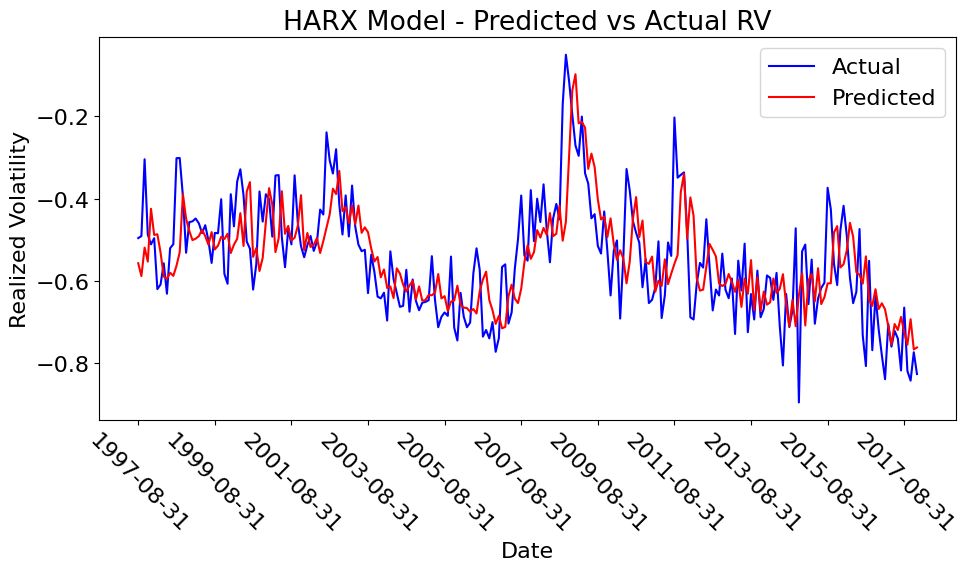

In [65]:
# Plotting the actual vs predicted values
plt.figure(figsize=(10, 6))
plt.rcParams['font.size'] = 16
plt.plot(test.index, actual, label='Actual', color='blue')
plt.plot(test.index, predictions_harx, label='Predicted', color='red')
plt.title('HARX Model - Predicted vs Actual RV')
plt.xlabel('Date')
plt.xticks(test.index[::24],rotation=-45)
plt.ylabel('Realized Volatility')
# plt.text(10, -1.5, 'diff_mean={:.5f}'.format(np.mean(actual-predictions_harx)), fontsize=16, color='black', ha='left')
# plt.text(10, -1.75, 'diff_var={:.5f}'.format(np.var(actual-predictions_harx)), fontsize=16, color='black', ha='left')
plt.legend()
plt.tight_layout() 
plt.savefig("HARX_model.png")
plt.show()

In [66]:
# Example usage with your data
qlike_loss = compute_qlike(np.array(predictions_harx), np.array(actual))
print(f"QLIKE Loss: {qlike_loss}")


QLIKE Loss: 7.9992113914950504


## AR(1) and AR(3)

In [67]:
# =============================================================================
# AR(1) and AR(3) Models — Autoregressive Baselines
# =============================================================================
# Simple autoregressive models that predict RV using only its own past values.
#   AR(1): RV_t = c + phi_1 * RV_{t-1} + epsilon_t
#   AR(3): RV_t = c + phi_1 * RV_{t-1} + phi_2 * RV_{t-2} + phi_3 * RV_{t-3} + epsilon_t
#
# Both use a fixed-size rolling window (571 months) per the paper methodology.
# Estimated via OLS (statsmodels AutoReg).
# =============================================================================

# Convert index to PeriodIndex (required by statsmodels AutoReg for time series)
dff.index = pd.DatetimeIndex(dff.index).to_period('M')

def rolling_forecast_ar(data, order, train_size):
    """
    Produce rolling-window AR(p) forecasts with FIXED window size.
    
    Parameters
    ----------
    data : pd.Series
        Full RV time series (816 months).
    order : int
        AR lag order (1 or 3).
    train_size : int
        Fixed training window size (571).
    
    Returns
    -------
    predictions : list
        245 out-of-sample predictions.
    actual : pd.Series
        Corresponding actual values.
    """
    predictions = []
    for end in range(train_size, len(data)):
        start = end - train_size  # Fixed-size rolling window
        train_data = data[start:end]
        model = AutoReg(train_data, lags=order, old_names=False)
        model_fit = model.fit()
        # Predict 1 step ahead (the month immediately after training window)
        pred = model_fit.predict(start=len(train_data), end=len(train_data), dynamic=False)
        predictions.append(pred.iloc[0])
    actual = data[train_size:]
    return predictions, actual

def compute_metrics(predictions, actual):
    """Compute MSE, RMSE, MAE, and MAPE between predictions and actual."""
    mse = mean_squared_error(actual, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, predictions)
    mape = np.mean(np.abs((actual - predictions) / actual)) * 100
    return mse, rmse, mae, mape

def compute_hit_rate(predictions, actual):
    """Fraction of correctly predicted directional changes."""
    predictions = np.array(predictions)
    actual = np.array(actual)
    pred_direction = (np.diff(predictions) > 0).astype(int)
    actual_direction = (np.diff(actual) > 0).astype(int)
    hits = np.sum(pred_direction == actual_direction)
    hit_rate = hits / len(pred_direction)
    return hit_rate

series = dff['RV'].dropna()
train_size = len(dff) - 245  # = 571

# Run both AR models
predictions_ar1, actual_ar1 = rolling_forecast_ar(series, 1, train_size)
predictions_ar3, actual_ar3 = rolling_forecast_ar(series, 3, train_size)

# Print metrics
mse_ar1, rmse_ar1, mae_ar1, mape_ar1 = compute_metrics(predictions_ar1, actual_ar1)
hit_rate_ar1 = compute_hit_rate(predictions_ar1, actual_ar1)
mse_ar3, rmse_ar3, mae_ar3, mape_ar3 = compute_metrics(predictions_ar3, actual_ar3)
hit_rate_ar3 = compute_hit_rate(predictions_ar3, actual_ar3)

print('AR(1) Model Metrics:')
print(f'Hit Rate: {hit_rate_ar1}')
print(f'Mean Square Error (MSE): {mse_ar1}')
print(f'Root Mean Square Error (RMSE): {rmse_ar1}')
print(f'Mean Absolute Error (MAE): {mae_ar1}')
print(f'Mean Absolute Percentage Error (MAPE): {mape_ar1}%')

print('\nAR(3) Model Metrics:')
print(f'Hit Rate: {hit_rate_ar3}')
print(f'Mean Square Error (MSE): {mse_ar3}')
print(f'Root Mean Square Error (RMSE): {rmse_ar3}')
print(f'Mean Absolute Error (MAE): {mae_ar3}')
print(f'Mean Absolute Percentage Error (MAPE): {mape_ar3}%')


AR(1) Model Metrics:
Hit Rate: 0.38934426229508196
Mean Square Error (MSE): 0.010543708371562821
Root Mean Square Error (RMSE): 0.10268256118525103
Mean Absolute Error (MAE): 0.07822721170703524
Mean Absolute Percentage Error (MAPE): 19.12149374231649%

AR(3) Model Metrics:
Hit Rate: 0.38524590163934425
Mean Square Error (MSE): 0.009522641064798174
Root Mean Square Error (RMSE): 0.09758402054024098
Mean Absolute Error (MAE): 0.0751137656022414
Mean Absolute Percentage Error (MAPE): 18.4795888929103%


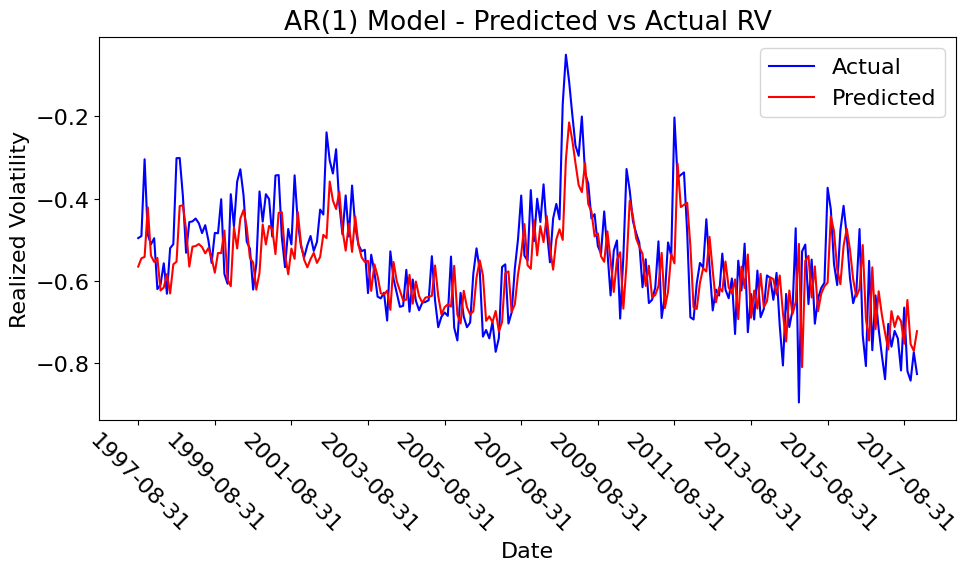

In [68]:
# Plotting the actual vs predicted values
plt.figure(figsize=(10, 6))
plt.rcParams['font.size'] = 16
plt.plot(test.index, actual, label='Actual', color='blue')
plt.plot(test.index, predictions_ar1, label='Predicted', color='red')
plt.title('AR(1) Model - Predicted vs Actual RV')
plt.xlabel('Date')
plt.xticks(test.index[::24],rotation=-45)
plt.ylabel('Realized Volatility')
# plt.text(10, -1.5, 'diff_mean={:.5f}'.format(np.mean(actual-predictions_ar1)), fontsize=16, color='black', ha='left')
# plt.text(10, -1.75, 'diff_var={:.5f}'.format(np.var(actual-predictions_ar1)), fontsize=16, color='black', ha='left')
plt.legend()
plt.tight_layout() 
plt.savefig("AR(1)_model.png")
plt.show()

In [69]:
# Example usage with your data
qlike_loss = compute_qlike(np.array(predictions_ar1), np.array(actual))
print(f"QLIKE Loss: {qlike_loss}")

QLIKE Loss: 6.0173160755927775


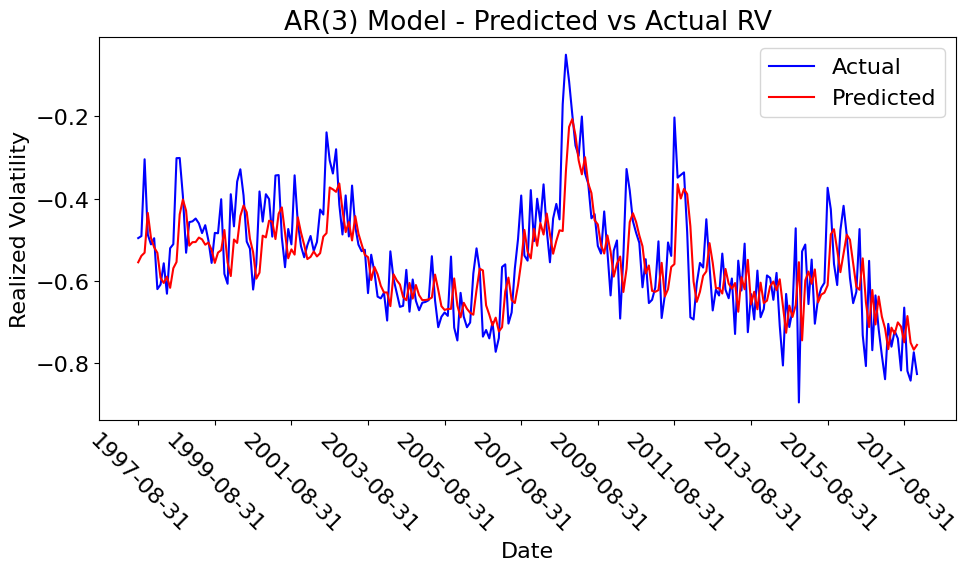

In [70]:
# Plotting the actual vs predicted values
plt.figure(figsize=(10, 6))
plt.rcParams['font.size'] = 16
plt.plot(test.index, actual, label='Actual', color='blue')
plt.plot(test.index, predictions_ar3, label='Predicted', color='red')
plt.title('AR(3) Model - Predicted vs Actual RV')
plt.xlabel('Date')
plt.xticks(test.index[::24],rotation=-45)
plt.ylabel('Realized Volatility')
# plt.text(10, -1.5, 'diff_mean={:.5f}'.format(np.mean(actual-predictions_ar3)), fontsize=16, color='black', ha='left')
# plt.text(10, -1.75, 'diff_var={:.5f}'.format(np.var(actual-predictions_ar3)), fontsize=16, color='black', ha='left')
plt.legend()
plt.tight_layout() 
plt.savefig("AR(3)_model.png")
plt.show()

In [71]:
# Example usage with your data
qlike_loss = compute_qlike(np.array(predictions_ar3), np.array(actual))
print(f"QLIKE Loss: {qlike_loss}")

QLIKE Loss: 5.656256514443295


our MCS analysis results suggest the following:

Model 3 is the only model included in the Model Confidence Set. This is indicated by its p-value of 1.0000, which implies that it comfortably fits within the set of best-performing models.

The other models (0, 1, and 2) are excluded from the MCS. Their p-values (0.0060 for models 0 and 2, and 0.0045 for model 1) are all below the typical significance threshold (e.g., 0.05), indicating that these models are statistically different from the best-performing model in terms of forecasting performance.

In summary, Model 3 is the top performer among the models you tested, while the others do not perform as well in comparison, based on the chosen loss function and the MCS methodology.

In the context of the Model Confidence Set (MCS) analysis, bootstrapping does not typically involve re-estimating the models multiple times. Instead, it uses the predicted values from the main model(s) and applies resampling techniques to these predictions. The essence of bootstrapping here is to create many synthetic samples (reps) from the original dataset by resampling with replacement. The MCS procedure then uses these samples to evaluate the stability and robustness of the model performance measures (like loss functions) across different simulated scenarios. This approach helps in assessing the statistical significance of the model performance differences.

## ARMAX

In [72]:
# =============================================================================
# ARMAX Model — AR(3) with eXogenous Macro Variables
# =============================================================================
# ARMAX extends AR(3) by adding all available macro-financial predictors as
# exogenous inputs. The model is:
#   RV_t = c + phi_1*RV_{t-1} + phi_2*RV_{t-2} + phi_3*RV_{t-3}
#          + sum_k( gamma_k * X_{k,t-1} ) + epsilon_t
#
# Paper specification: AR order = (3, 0, 0) with exogenous variables.
# Estimated via MLE (statsmodels ARIMA with exog).
# Uses fixed-size rolling window (571 months) per paper methodology.
# =============================================================================

def rolling_forecast_armax(data, exog_data, order, train_size):
    """
    Rolling-window ARMAX forecast with fixed window size.
    
    Parameters
    ----------
    data : pd.Series
        Target variable (RV).
    exog_data : pd.DataFrame
        Exogenous variables (lagged macro features).
    order : tuple
        ARIMA order (p, d, q). Paper: (3, 0, 0).
    train_size : int
        Fixed window size (571).
    """
    predictions = []
    for end in range(train_size, len(data)):
        start = end - train_size  # Fixed-size rolling window
        train_data = data[start:end]
        exog_train = exog_data[start:end]
        model = ARIMA(train_data, order=order, exog=exog_train, trend='n')
        model_fit = model.fit(method_kwargs={'warn_convergence': False})
        exog_test = exog_data.iloc[end:end+1]
        pred = model_fit.forecast(exog=exog_test)
        predictions.append(pred.iloc[0])
    actual = data[train_size:]
    return predictions, actual

def compute_metrics(predictions, actual):
    """Compute MSE, RMSE, MAE, MAPE."""
    mse = mean_squared_error(actual, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, predictions)
    mape = np.mean(np.abs((actual - predictions) / actual)) * 100
    return mse, rmse, mae, mape

def compute_hit_rate(predictions, actual):
    """Fraction of correctly predicted directional changes."""
    predictions = np.array(predictions)
    actual = np.array(actual)
    pred_direction = (np.diff(predictions) > 0).astype(int)
    actual_direction = (np.diff(actual) > 0).astype(int)
    hits = np.sum(pred_direction == actual_direction)
    return hits / len(pred_direction)

# Prepare exogenous variables: lag ALL non-RV columns by 1 period
exog_vars = dff.drop(columns=['RV']).shift(1).dropna()
series = dff['RV'].dropna()
series, exog_vars = series.align(exog_vars, join='inner')  # Align indices
train_size = len(series) - 245

# Paper: ARMAX uses AR(3) order
order = (3, 0, 0)
predictions_armax, actual_armax = rolling_forecast_armax(series, exog_vars, order, train_size)

mse_armax, rmse_armax, mae_armax, mape_armax = compute_metrics(predictions_armax, actual_armax)
hit_rate_armax = compute_hit_rate(predictions_armax, actual_armax)

print('ARMAX Model Metrics:')
print(f'Hit Rate: {hit_rate_armax}')
print(f'Mean Square Error (MSE): {mse_armax}')
print(f'Root Mean Square Error (RMSE): {rmse_armax}')
print(f'Mean Absolute Error (MAE): {mae_armax}')
print(f'Mean Absolute Percentage Error (MAPE): {mape_armax}%')


ARMAX Model Metrics:
Hit Rate: 0.4262295081967213
Mean Square Error (MSE): 0.008400794761733608
Root Mean Square Error (RMSE): 0.09165584957728344
Mean Absolute Error (MAE): 0.06932139643495688
Mean Absolute Percentage Error (MAPE): 15.765907757849149%


In [73]:
# mse_armax, rmse_armax, mae_armax, mape_armax = compute_metrics(predictions_qr2, actual_armax)
# print("QR2 Model Metrics:")
# print(f"Hit Rate: {hit_rate_armax}")
# print(f"Mean Square Error (MSE): {mse_armax}")
# print(f"Root Mean Square Error (RMSE): {rmse_armax}")
# print(f"Mean Absolute Error (MAE): {mae_armax}")
# print(f"Mean Absolute Percentage Error (MAPE): {mape_armax}%")

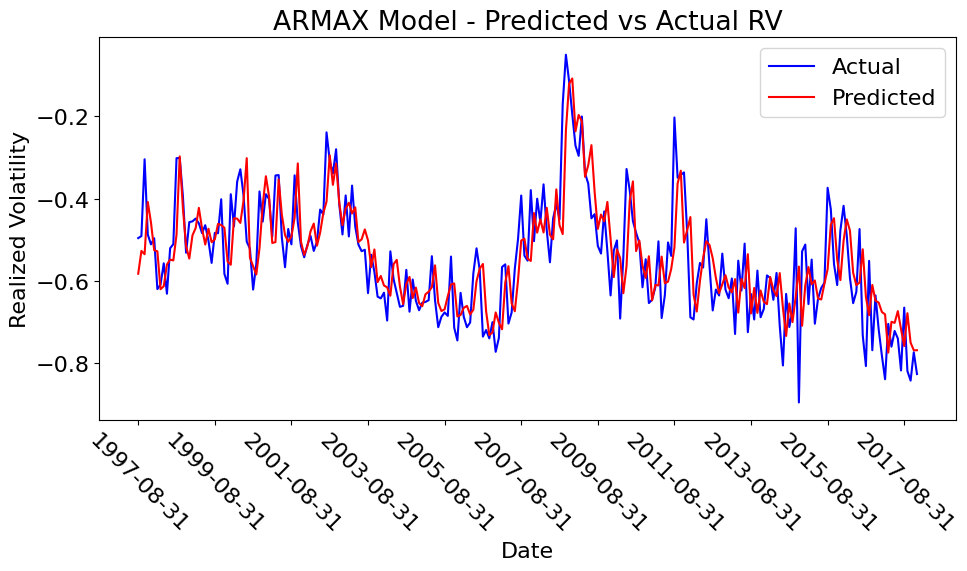

In [74]:
# Plotting the actual vs predicted values
plt.figure(figsize=(10, 6))
plt.rcParams['font.size'] = 16
plt.plot(test.index, actual, label='Actual', color='blue')
plt.plot(test.index, predictions_armax, label='Predicted', color='red')
plt.title('ARMAX Model - Predicted vs Actual RV')
plt.xlabel('Date')
plt.xticks(test.index[::24],rotation=-45)
plt.ylabel('Realized Volatility')
# plt.text(10, -1.5, 'diff_mean={:.5f}'.format(np.mean(actual-predictions_armax)), fontsize=16, color='black', ha='left')
# plt.text(10, -1.75, 'diff_var={:.5f}'.format(np.var(actual-predictions_armax)), fontsize=16, color='black', ha='left')
plt.legend()
plt.tight_layout() 
plt.savefig("ARMAX_model.png")
plt.show()

In [75]:
# Example usage with your data
qlike_loss = compute_qlike(np.array(predictions_armax), np.array(actual))
print(f"QLIKE Loss: {qlike_loss}")

QLIKE Loss: 5.177594163681439


In [76]:
# =============================================================================
# Load Quantum Reservoir Predictions (QR1 and QR2)
# =============================================================================
# predict_result.csv is a pre-computed artifact from the Julia quantum
# simulation pipeline (Time_serial_Finance_regression.ipynb). It contains
# 245 out-of-sample predictions for two quantum reservoir models:
#   - QR1: Single reservoir (10 qubits, features: RV,MKT,DP,IP,RV_q,STR,DEF)
#   - QR2: Ensemble reservoir (2 reservoirs with tau and tau/2 evolution)
#
# IMPORTANT SCALE CONVERSION:
# The Julia code outputs predictions in the DENORMALIZED log-RV scale
# (range approximately [-3.9, -1.7]), but all Python models work in the
# NORMALIZED scale (range [-1, 0]) as stored in Data.CSV.
#
# The Julia denormalization formula is:
#   denorm_val = (norm_val + 1) * dif + Min_RV
#
# So the inverse (to get back to normalized scale) is:
#   norm_val = (denorm_val - Min_RV) / dif - 1
#
# These constants come from Time_series.jl lines 33-34.
# =============================================================================
Max_RV = -1.2543188032019446  # Maximum log-RV in the original dataset
Min_RV = -4.7722718186046515  # Minimum log-RV in the original dataset
dif = Max_RV - Min_RV         # Scale range = 3.5180 (used for normalization)

# Load the denormalized QR predictions
QR_all_pred = pd.read_csv("predict_result.csv", header=0, index_col=False)

# Convert back to normalized [-1, 0] scale to match all other models
predictions_qr1 = np.array((QR_all_pred["QR1"] - Min_RV) / dif - 1)
predictions_qr2 = np.array((QR_all_pred["QR2"] - Min_RV) / dif - 1)

# Sanity check: values should be in approximately [-1, 0]
print(f"QR1: range=[{predictions_qr1.min():.4f}, {predictions_qr1.max():.4f}], mean={predictions_qr1.mean():.4f}")
print(f"QR2: range=[{predictions_qr2.min():.4f}, {predictions_qr2.max():.4f}], mean={predictions_qr2.mean():.4f}")


QR1: range=[-0.7332, -0.1660], mean=-0.5397
QR2: range=[-0.7548, -0.1172], mean=-0.5509


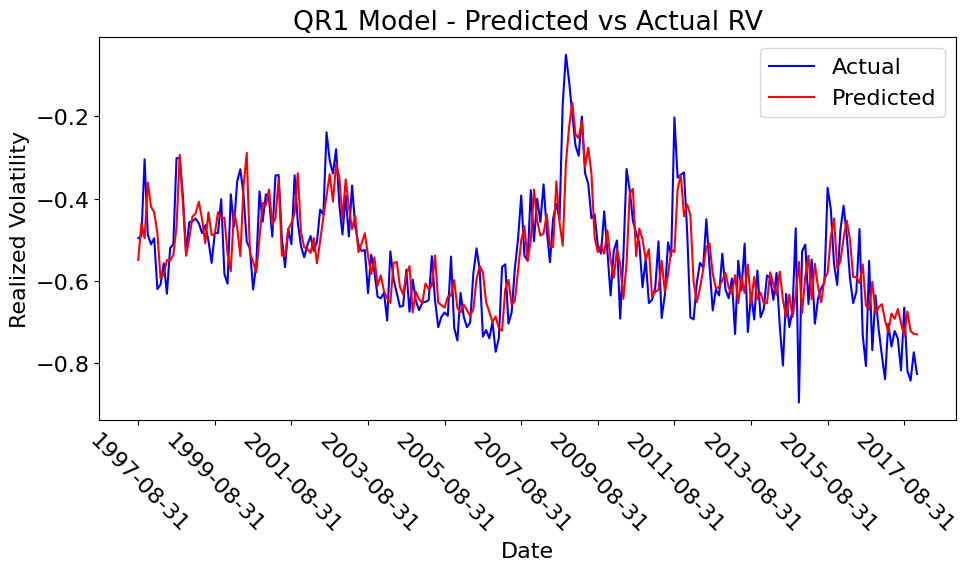

In [77]:
# Plotting the actual vs predicted values
plt.figure(figsize=(10, 6))
plt.rcParams['font.size'] = 16
plt.plot(test.index, actual, label='Actual', color='blue')
plt.plot(test.index, predictions_qr1, label='Predicted', color='red')
plt.title('QR1 Model - Predicted vs Actual RV')
plt.xlabel('Date')
plt.xticks(test.index[::24],rotation=-45)
plt.ylabel('Realized Volatility')
# plt.text(10, -1.5, 'diff_mean={:.5f}'.format(np.mean(actual-predictions_qr1)), fontsize=16, color='black', ha='left')
# plt.text(10, -1.75, 'diff_var={:.5f}'.format(np.var(actual-predictions_qr1)), fontsize=16, color='black', ha='left')
plt.legend()
plt.tight_layout() 
plt.savefig("QR1_model.png")
plt.show()

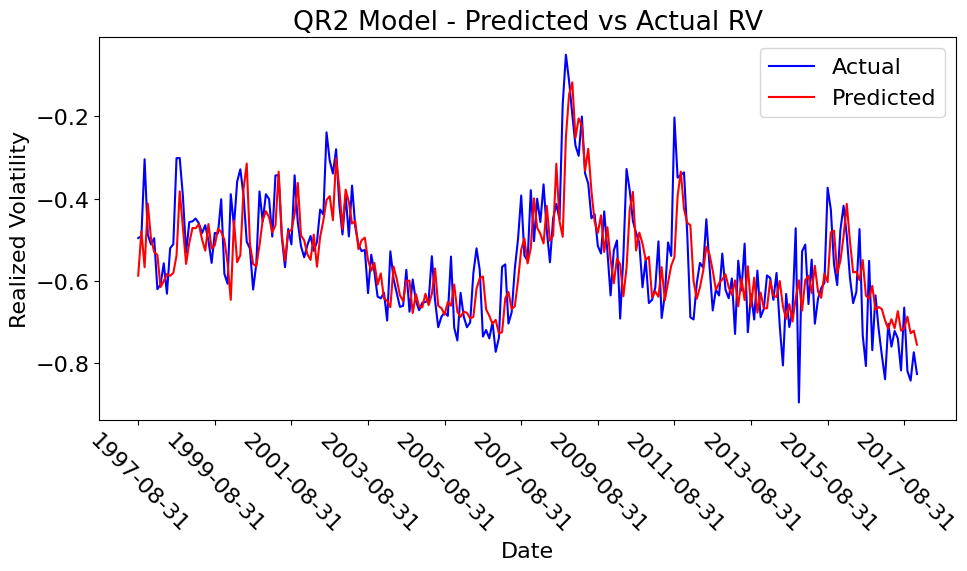

In [78]:
# Plotting the actual vs predicted values
plt.figure(figsize=(10, 6))
plt.rcParams['font.size'] = 16
plt.plot(test.index, actual, label='Actual', color='blue')
plt.plot(test.index, predictions_qr2, label='Predicted', color='red')
plt.title('QR2 Model - Predicted vs Actual RV')
plt.xlabel('Date')
plt.xticks(test.index[::24],rotation=-45)
plt.ylabel('Realized Volatility')
# plt.text(10, -1.5, 'diff_mean={:.5f}'.format(np.mean((actual-predictions_qr2))), fontsize=16, color='black', ha='left')
# plt.text(10, -1.75, 'diff_var={:.5f}'.format(np.var(actual-predictions_qr2)), fontsize=16, color='black', ha='left')
plt.legend()
plt.tight_layout() 
plt.savefig("QR2_model.png")
plt.show()

In [79]:
# =============================================================================
# Load LSTM and Classical Reservoir Predictions
# =============================================================================
# These were generated by LSTM.ipynb and classical_reservoir.ipynb.
# Each file contains 245 out-of-sample predictions (one per test month).
# =============================================================================

# LSTM predictions (fixed filenames from known best hyperparameters)
predictions_lstm = np.loadtxt("LSTM/lstm60_predictions.csv", delimiter=',')
predictions_lstmx = np.loadtxt("LSTM/lstmx50_predictions.csv", delimiter=',')

# Classical reservoir predictions (filename includes best N value)
# Use glob to find files matching the pattern, in case N varies between runs
crl_files = sorted(globmod.glob("Classical_Reservoir_learning/best_CRL(*_predictions.csv"))
crlx_files = sorted(globmod.glob("Classical_Reservoir_learning/best_CRLX(*_predictions.csv"))
assert len(crl_files) >= 1, f"No CRL prediction files found — run classical_reservoir.ipynb first"
assert len(crlx_files) >= 1, f"No CRLX prediction files found — run classical_reservoir.ipynb first"
print(f"Loading CRL: {crl_files[0]}")
print(f"Loading CRLX: {crlx_files[0]}")
predictions_crl = np.loadtxt(crl_files[0], delimiter=',')
predictions_crlx = np.loadtxt(crlx_files[0], delimiter=',')


Loading CRL: Classical_Reservoir_learning/best_CRL(50)_predictions.csv
Loading CRLX: Classical_Reservoir_learning/best_CRLX(20)_predictions.csv


In [80]:
# =============================================================================
# Model Confidence Set (MCS) — MSE Loss
# =============================================================================
# The MCS (Hansen, Lunde & Nason, 2011) identifies which models belong to
# the "best model set" — the group of models whose forecasting performance
# is statistically indistinguishable from the best.
#
# Configuration (per paper):
#   size=0.05    — 95% confidence level
#   method='R'   — Range-type test statistic T_{R,M}
#   bootstrap='stationary' — Politis & Romano stationary bootstrap
#   reps=10000   — bootstrap replications
#
# Interpretation:
#   - Models with p-value > 0.05 are INCLUDED in the best model set
#   - Model with p-value = 1.0 is the definitively best model
#   - Models with p-value < 0.05 are EXCLUDED (significantly worse)
#
# Paper expectation (Table II): QR2 should have p=1.0 (best), QR1 high p.
# =============================================================================
from arch.bootstrap import MCS

model_names = ['HAR','HARX','AR1','AR3','QR1','QR2','ARMAX','LSTM','LSTMX','CRL','CRLX']

# Compute squared errors (MSE loss) for each model
har_loss = (predictions_har - actual) ** 2
harx_loss = (predictions_harx - actual) ** 2
ar1_loss = (predictions_ar1 - actual) ** 2
ar3_loss = (predictions_ar3 - actual) ** 2
qr1_loss = (predictions_qr1 - actual) ** 2
qr2_loss = (predictions_qr2 - actual) ** 2
armax_loss = (predictions_armax - actual) ** 2
lstm_loss = (predictions_lstm - actual) ** 2
lstmx_loss = (predictions_lstmx - actual) ** 2
crl_loss = (predictions_crl - actual) ** 2
crlx_loss = (predictions_crlx - actual) ** 2

# Stack into (245, 11) loss matrix
losses = np.column_stack([har_loss, harx_loss, ar1_loss, ar3_loss, qr1_loss,
                          qr2_loss, armax_loss, lstm_loss, lstmx_loss, crl_loss, crlx_loss])
losses_df = pd.DataFrame(losses, columns=model_names)

try:
    mcs = MCS(losses_df, size=0.05, reps=10000, method='R', bootstrap='stationary')
    mcs.compute()
    print('MSE MCS included models:', mcs.included)
    print('MSE MCS p-values:')
    print(mcs.pvalues)
except Exception as e:
    print(f'MSE MCS computation failed: {e}')


MSE MCS included models: ['AR3', 'ARMAX', 'LSTMX', 'QR1', 'QR2']
MSE MCS p-values:
            Pvalue
Model name        
HAR         0.0028
AR1         0.0045
HARX        0.0060
CRLX        0.0353
LSTM        0.0466
CRL         0.0466
AR3         0.0563
LSTMX       0.0874
QR1         0.9492
ARMAX       0.9722
QR2         1.0000


In [81]:
np.mean((predictions_crlx-actual)**2)

np.float64(0.019638204016470297)

In [82]:
compute_qlike(np.array(predictions_crlx), np.array(actual))

np.float64(9.484325190118852)

In [83]:
# =============================================================================
# Model Confidence Set (MCS) — QLIKE Loss
# =============================================================================
# Same MCS procedure as above, but using QLIKE loss instead of MSE.
# QLIKE penalizes underestimation of volatility more heavily, giving
# a different perspective on model quality.
#
# Element-wise QLIKE loss for each model:
#   qloss_i = |actual|/|forecast| - log(|actual|/|forecast|) - 1
#
# Absolute values are needed because RV is in log-space (negative values).
# =============================================================================

# Compute element-wise QLIKE loss for each model (245 values each)
har_qloss = (np.abs(actual)/np.abs(predictions_har)-np.log(np.abs(actual)/np.abs(predictions_har))-1)
harx_qloss = (np.abs(actual)/np.abs(predictions_harx)-np.log(np.abs(actual)/np.abs(predictions_harx))-1)
ar1_qloss = (np.abs(actual)/np.abs(predictions_ar1)-np.log(np.abs(actual)/np.abs(predictions_ar1))-1)
ar3_qloss = (np.abs(actual)/np.abs(predictions_ar3)-np.log(np.abs(actual)/np.abs(predictions_ar3))-1)
qr1_qloss = (np.abs(actual)/np.abs(predictions_qr1)-np.log(np.abs(actual)/np.abs(predictions_qr1))-1)
qr2_qloss = (np.abs(actual)/np.abs(predictions_qr2)-np.log(np.abs(actual)/np.abs(predictions_qr2))-1)
armax_qloss = (np.abs(actual)/np.abs(predictions_armax)-np.log(np.abs(actual)/np.abs(predictions_armax))-1)
lstm_qloss = (np.abs(actual)/np.abs(predictions_lstm)-np.log(np.abs(actual)/np.abs(predictions_lstm))-1)
lstmx_qloss = (np.abs(actual)/np.abs(predictions_lstmx)-np.log(np.abs(actual)/np.abs(predictions_lstmx))-1)
crl_qloss = (np.abs(actual)/np.abs(predictions_crl)-np.log(np.abs(actual)/np.abs(predictions_crl))-1)
crlx_qloss = (np.abs(actual)/np.abs(predictions_crlx)-np.log(np.abs(actual)/np.abs(predictions_crlx))-1)

# Stack into (245, 11) QLIKE loss matrix
lossesq = np.column_stack([har_qloss, harx_qloss, ar1_qloss, ar3_qloss, qr1_qloss,
                           qr2_qloss, armax_qloss, lstm_qloss, lstmx_qloss, crl_qloss, crlx_qloss])
lossesq_df = pd.DataFrame(lossesq, columns=model_names)

try:
    mcsq = MCS(lossesq_df, size=0.05, reps=10000, method='R', bootstrap='stationary')
    mcsq.compute()
    print('QLIKE MCS included models:', mcsq.included)
    print('QLIKE MCS p-values:')
    p_valuesq = mcsq.pvalues
    print(p_valuesq)
except Exception as e:
    print(f'QLIKE MCS computation failed: {e}')


QLIKE MCS included models: ['AR1', 'AR3', 'ARMAX', 'CRL', 'HARX', 'LSTM', 'LSTMX', 'QR1', 'QR2']
QLIKE MCS p-values:
            Pvalue
Model name        
CRLX        0.0331
HAR         0.0366
AR1         0.0610
LSTMX       0.1555
LSTM        0.2025
CRL         0.2025
HARX        0.2025
AR3         0.2025
QR1         0.5984
ARMAX       0.6849
QR2         1.0000


In [84]:
f=['har','harx']

In [85]:
p_valuesq.index

Index(['CRLX', 'HAR', 'AR1', 'LSTMX', 'LSTM', 'CRL', 'HARX', 'AR3', 'QR1',
       'ARMAX', 'QR2'],
      dtype='str', name='Model name')

In [86]:
# =============================================================================
# Diebold-Mariano (DM) Pairwise Significance Test
# =============================================================================
# The DM test (Diebold & Mariano, 1995) tests whether two forecasting
# models have significantly different predictive accuracy.
#
# Test statistic:
#   DM = d_bar / sqrt(sigma_hat^2 / T)
#
# Where:
#   d_t = e1_t^2 - e2_t^2  (loss differential at time t)
#   d_bar = mean(d_t)       (average loss differential)
#   sigma_hat^2 = Newey-West HAC variance (corrects for serial correlation)
#
# The Newey-West estimator uses a Bartlett kernel with bandwidth T^(1/3).
# This is important because forecast errors are typically serially correlated,
# and naive variance estimates would understate uncertainty.
#
# Paper reference: Table III
# =============================================================================
from scipy.stats import t as t_dist

def diebold_mariano_test(actual, pred1, pred2):
    """
    Conduct the Diebold-Mariano test with Newey-West HAC variance.
    
    A positive DM statistic means pred1 is WORSE than pred2 (higher loss).
    A negative DM statistic means pred1 is BETTER.
    p-value < 0.05 means the difference is statistically significant.
    
    Parameters
    ----------
    actual : array-like
        True RV values (245 months).
    pred1, pred2 : array-like
        Predictions from two competing models.
    
    Returns
    -------
    dm_stat : float
        DM test statistic.
    p_value : float
        Two-sided p-value (significant if < 0.05).
    """
    e1 = np.array(actual) - np.array(pred1)
    e2 = np.array(actual) - np.array(pred2)

    # Loss differential: positive means pred1 has higher loss (is worse)
    d = np.square(e1) - np.square(e2)
    T = len(d)
    mean_d = np.mean(d)

    # Newey-West HAC variance estimate
    # Bandwidth = floor(T^(1/3)) — standard choice for HAC estimators
    max_lag = int(np.floor(T ** (1.0 / 3.0)))
    d_demean = d - mean_d
    gamma_0 = np.dot(d_demean, d_demean) / T  # Variance at lag 0
    nw_var = gamma_0
    for k in range(1, max_lag + 1):
        weight = 1.0 - k / (max_lag + 1.0)  # Bartlett kernel weight
        gamma_k = np.dot(d_demean[k:], d_demean[:-k]) / T  # Autocovariance at lag k
        nw_var += 2 * weight * gamma_k  # Add weighted autocovariance (symmetric)

    # DM statistic and two-sided p-value (t-distribution)
    dm_stat = mean_d / np.sqrt(nw_var / T)
    p_value = 2 * t_dist.cdf(-abs(dm_stat), df=T - 1)

    return dm_stat, p_value

# List of all 11 models' predictions for pairwise comparison
pre = [predictions_qr1, predictions_qr2, predictions_har, predictions_harx,
       predictions_ar3, predictions_ar1, predictions_armax,
       predictions_lstm, predictions_lstmx, predictions_crl, predictions_crlx]

# Quick check: HAR vs HARX
dm_stat_test, p_value_test = diebold_mariano_test(actual, predictions_har, predictions_harx)
print(f"DM test (HAR vs HARX): stat={dm_stat_test:.4f}")


0.23108749788037095


In [87]:
# Initialize 11x11 matrices for pairwise DM test results
# dm_stat[i,j] = DM statistic comparing model i vs model j
# p_value[i,j] = corresponding p-value
# Only upper triangle is filled (j > i); lower triangle remains 0.
dm_stat = np.zeros((11, 11))
p_value = np.zeros((11, 11))


In [88]:
# =============================================================================
# Compute all pairwise DM tests (55 unique pairs from 11 models)
# =============================================================================
# This produces the DM test table reported in Table III of the paper.
# Model order: QR1, QR2, HAR, HARX, AR3, AR1, ARMAX, LSTM, LSTMX, CRL, CRLX
for i in range(11):
    for j in range(i+1, 11):
        dm_stat[i,j], p_value[i,j] = diebold_mariano_test(actual, pre[i], pre[j])


In [89]:
# Save DM test statistics matrix to CSV
# Rows/columns: QR1, QR2, HAR, HARX, AR3, AR1, ARMAX, LSTM, LSTMX, CRL, CRLX
np.savetxt("dm_stat.csv", dm_stat, delimiter=',', fmt='%3f')


In [90]:
# Save DM test p-values matrix to CSV
np.savetxt("p_value.csv", p_value, delimiter=',', fmt='%3f')
